# Image classification from scratch

本示例将演示如何从零开始实现图像分类 —— 直接基于磁盘中的 JPEG 图像文件，不借助预训练权重或现成的 Keras 应用模型。我们将以 Kaggle 平台的猫狗二分类数据集为例，完整展示这一实现流程。

本文中，我们将使用image_dataset_from_directory工具生成数据集，并通过 Keras 图像预处理层完成图像标准化与数据增强操作。

Ref: https://keras.io/examples/vision/image_classification_from_scratch/

## Setup

In [1]:
# Import necessary libraries
import os
import numpy as np
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

c:\ProgramData\anaconda3\envs\pytorch\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Load the data: the Cats vs Dogs dataset

### Raw data

In [2]:
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0   0     0   0     0     0     0  --:--:-- --:--:-- --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:01 --:--:--     0
  0 786.6M   0  3871k   0     0  2069k     0   0:06:29  0:00:01  0:06:28  2070k
  1 786.6M   1 11199k   0     0  3901k     0   0:03:26  0:00:02  0:03:24  3902k
  2 786.6M   2 18463k   0     0  4769k     0   0:02:48  0:00:03  0:02:45  4770k
  3 786.6M   3 25743k   0     0  5285k     0   0:02:32  0:00:04  0:02:28  5286k
  4 786.6M   4 33039k   0     0  5626k     0   0:02:23  0:00:05  0:02:18  7099k
  5 786.6M   5 40287k   0     0  5863k     0   0:02:17  0:00:06  0:02:11  7283k
  5 786.6M   5 47567k   0     0  6040k     0   0:02:13  0:00:07  0:02:06  7269k
  6 786.6M   6 54783k   0     0  6175k     0   0:02:10  0:00:08  0:02:02  7264k
  7 786.6M   7 61999k   0     0  6279k     0   0:

In [4]:
# 解压到Res文件夹
!unzip -q kagglecatsanddogs_5340.zip -d Res

'rm' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


### Filter out corrupted images
**过滤损坏的图像**

处理大量实际场景的图像数据时，图像损坏是常见问题。我们来过滤掉那些文件头中不包含 “JFIF” 标识的编码异常图像。

In [7]:
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(RES_DIR, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 1578 images.


## Generate a Dataset

In [2]:
RES_DIR = 'Res/PetImages'
image_size = (180, 180)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    RES_DIR,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 23422 files belonging to 2 classes.
Using 18738 files for training.
Using 4684 files for validation.


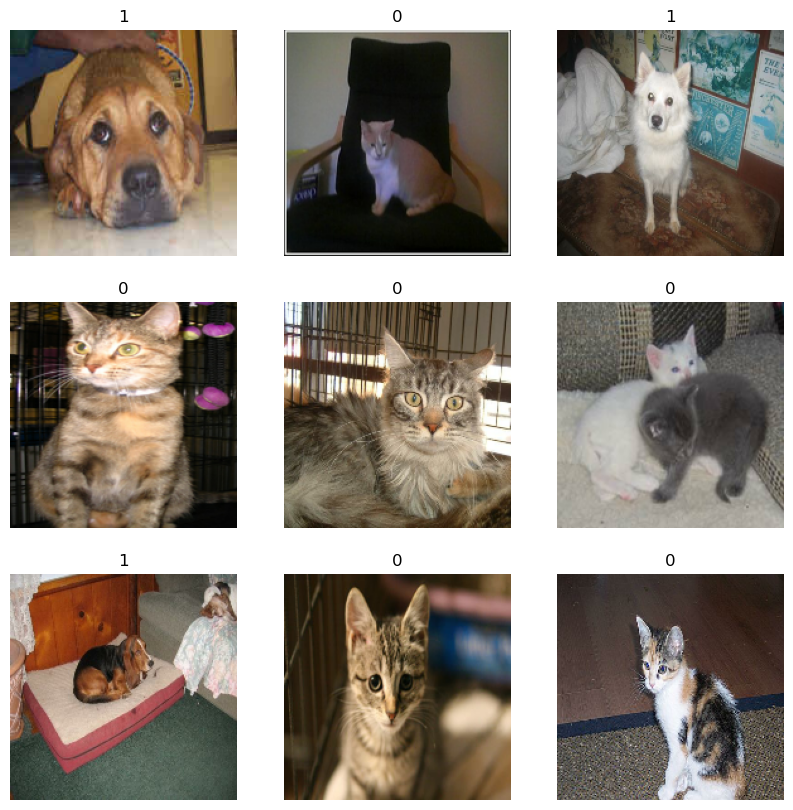

In [9]:
# Visualize the data
# Here are the first 9 images in the training dataset.
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")


## Using image data augmentation

当你没有大规模的图像数据集时，一个实用的做法是对训练图像施加随机且贴合实际的变换来人为增加样本多样性，比如随机水平翻转或小角度随机旋转。这一做法能让模型接触到训练数据的不同特征维度，同时减缓过拟合现象的发生。

In [3]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

## Configure the dataset for performance

In [4]:
# Apply `data_augmentation` to the training images.
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)


## Build a model

我们将搭建一个轻量版的 Xception 网络。本示例并未专门对网络架构做优化调优；若你想要系统性地搜索最优模型配置，可考虑使用 KerasTuner 工具。

**注意事项**：

模型的首层为数据增强预处理层，其后衔接一个缩放层；

最终分类层前加入了一个丢弃层。

In [5]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x) 
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [64, 128, 512]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(512, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(units, activation=None)(x)
    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=2)

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 180, 180,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 90, 90,    │      1,792 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 90, 90,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 90, 90,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 90, 90,    │          0 │ activation[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 90, 90,    │      4,736 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 90,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 90, 90,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 90, 90,    │      4,736 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 90,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 45, 45,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 45, 45,    │      4,160 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 45, 45,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 45, 45,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 45, 45,    │      8,896 │ activation_3[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 45,    │        512 │ separable_conv2d

 Total params: 726,529 (2.77 MB)

 Trainable params: 722,561 (2.76 MB)

 Non-trainable params: 3,968 (15.50 KB)

## Train the model

In [7]:
epochs = 25
# 启用混合精度训练
keras.mixed_precision.set_global_policy("mixed_float16")

callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")],
)
model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)


Epoch 1/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - acc: 0.6792 - loss: 0.5793 - val_acc: 0.5446 - val_loss: 0.7258
Epoch 2/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - acc: 0.7708 - loss: 0.4640 - val_acc: 0.8128 - val_loss: 0.4546
Epoch 3/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - acc: 0.8110 - loss: 0.3974 - val_acc: 0.6800 - val_loss: 0.5678
Epoch 4/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - acc: 0.8321 - loss: 0.3599 - val_acc: 0.8482 - val_loss: 0.3340
Epoch 5/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - acc: 0.8548 - loss: 0.3225 - val_acc: 0.8369 - val_loss: 0.3138
Epoch 6/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - acc: 0.8658 - loss: 0.2966 - val_acc: 0.8984 - val_loss: 0.2586
Epoch 7/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - acc: 0.8762 - loss: 0.2756 - val_acc: 0.8915 - val_loss: 0.2829
Epoch 8/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - acc: 0.8819 - loss: 0.2591 - val_acc: 0.9020 - val_loss: 0.2223
Epoch 9/25
586/586 ━━━━━━━━━━━━━━━━━━━━ 

## Run inference on new data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
This image is 22.56% cat and 77.44% dog.


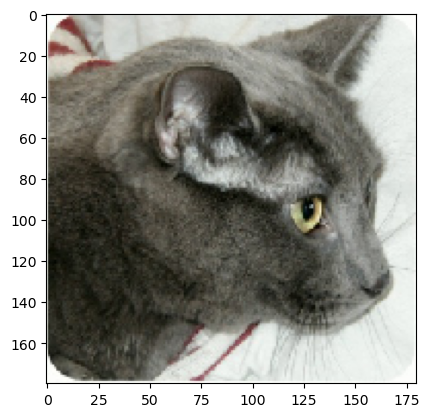

In [9]:
img = keras.utils.load_img(os.path.join(RES_DIR, "Cat/6779.jpg"), target_size=image_size)
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = keras.ops.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
score = float(keras.ops.sigmoid(predictions[0][0]))
print(f"This image is {100 * (1 - score):.2f}% cat and {100 * score:.2f}% dog.")
